In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import seaborn as sns
import matplotlib.pyplot as plt

In [75]:
# Clean Data

def load_yfinance_csv(path, ticker):
    asset = pd.read_csv(path)
    asset = asset.iloc[2:].copy()
    asset = asset.rename(columns={"Price": "Date", "Adj Close": ticker})
    asset = asset[["Date", ticker]].copy()
    asset["Date"] = pd.to_datetime(asset["Date"], errors="coerce")
    asset[ticker] = pd.to_numeric(asset[ticker], errors="coerce")
    asset = asset.dropna(subset=["Date", ticker])
    return asset


schb = load_yfinance_csv("Data/SCHB_daily.csv", "SCHB")
vti = load_yfinance_csv("Data/VTI_daily.csv", "VTI")

df = schb.merge(vti, on="Date", how="inner")
df = df.sort_values("Date").reset_index(drop=True)
df = df[(df["SCHB"]>0) & (df["VTI"]>0)].copy()

df["log_SCHB"] = np.log(df["SCHB"])
df["log_VTI"] = np.log(df["VTI"])
df = df.dropna().reset_index(drop=True)

df.head()

,Date,SCHB,VTI,log_SCHB,log_VTI
0,2009-11-03,3.104021,39.376068,1.132698,3.673158
1,2009-11-04,3.107810,39.443298,1.133918,3.674864
2,2009-11-05,3.168450,40.197800,1.153242,3.693812
3,2009-11-06,3.177294,40.302395,1.156030,3.696411
4,2009-11-09,3.249305,41.206310,1.178441,3.718591


In [76]:
# Defining periods for training, validation and testing

TRAIN_START = "2010-01-01"
TRAIN_END = "2015-12-31"

VALID_START = "2016-01-01"
VALID_END = "2021-12-31"

TEST_START = "2022-01-01"

training_set = df[(df["Date"]>=TRAIN_START) & (df["Date"]<=TRAIN_END)]
validation_set = df[(df["Date"]>=VALID_START) & (df["Date"]<=VALID_END)]
test_set = df[df["Date"]>=TEST_START]

In [77]:
# Variables to hyperparameter tune

# Tune these first because they change the Kalman spread itself.
KALMAN_PARAM_GRID = [
    {"q_alpha": 1e-6, "q_beta": 1e-6, "r": 1e-3},
    {"q_alpha": 1e-5, "q_beta": 1e-6, "r": 1e-3},
    {"q_alpha": 1e-6, "q_beta": 1e-5, "r": 1e-3},
    {"q_alpha": 1e-5, "q_beta": 1e-5, "r": 1e-3},
    {"q_alpha": 1e-4, "q_beta": 1e-5, "r": 1e-3},
    {"q_alpha": 1e-5, "q_beta": 1e-4, "r": 1e-3},
    {"q_alpha": 1e-4, "q_beta": 1e-4, "r": 1e-3},
    {"q_alpha": 1e-5, "q_beta": 1e-5, "r": 1e-4},
    {"q_alpha": 1e-5, "q_beta": 1e-5, "r": 1e-2},
]

# Hold these fixed while tuning Kalman parameters. Tune them later in separate passes.
Z_LOOKBACK = 60
ENTRY_Z = 1.5
EXIT_Z = 0.5
POSITION_LIMIT = 1000

Z_LOOKBACKS = list(range(5,35))
ENTRY_ZS = [x / 10 for x in range(5, 26)]
EXIT_ZS = [x / 10 for x in range(1, 16)]


In [78]:
def kalman_filter_beta(y, x, q_alpha=1e-5, q_beta=1e-5, r=1e-3):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)

    n = len(y)

    alpha_series = np.full(n, np.nan)
    beta_series = np.full(n, np.nan)
    spread_series = np.full(n, np.nan)

    # Initial state: [alpha, beta]
    theta = np.array([0.0, 1.0])

    P = np.eye(2)

    Q = np.array([
        [q_alpha, 0.0],
        [0.0, q_beta]
    ])

    R = r

    for t in range(n):
        H = np.array([1.0, x[t]])

        theta_pred = theta
        P_pred = P + Q

        y_pred = H @ theta_pred

        innovation = y[t] - y_pred

        S = H @ P_pred @ H.T + R

        K = P_pred @ H.T / S

        theta = theta_pred + K * innovation
        P = P_pred - np.outer(K, H) @ P_pred

        alpha_series[t] = theta[0]
        beta_series[t] = theta[1]
        spread_series[t] = y[t] - theta[0] - theta[1] * x[t]

    return pd.DataFrame({
        "alpha_kalman": alpha_series,
        "beta_kalman": beta_series,
        "spread": spread_series
    })

In [79]:
# Tune only Kalman filter parameters using the training and validation sets

def prepare_kalman_set(source_df, q_alpha, q_beta, r, z_lookback=Z_LOOKBACK):
    result = source_df.copy().reset_index(drop=True)
    kalman_result = kalman_filter_beta(
        y=result["log_VTI"],
        x=result["log_SCHB"],
        q_alpha=q_alpha,
        q_beta=q_beta,
        r=r
    )
    result = pd.concat([result, kalman_result], axis=1)
    result["spread_mean"] = result["spread"].rolling(z_lookback).mean()
    result["spread_std"] = result["spread"].rolling(z_lookback).std()
    result["z"] = (result["spread"] - result["spread_mean"]) / result["spread_std"]
    return result


def generate_positions(df, entry_z=ENTRY_Z, exit_z=EXIT_Z, position_limit=POSITION_LIMIT):
    result = df.copy()
    positions = []
    current_pos = 0

    for z in result["z"]:
        if pd.isna(z):
            positions.append(current_pos)
            continue

        if current_pos == 0:
            if z > entry_z:
                current_pos = -position_limit
            elif z < -entry_z:
                current_pos = position_limit
        elif current_pos > 0 and z >= -exit_z:
            current_pos = 0
        elif current_pos < 0 and z <= exit_z:
            current_pos = 0

        positions.append(current_pos)

    result["position"] = positions
    return result


def run_spread_backtest(df, entry_z=ENTRY_Z, exit_z=EXIT_Z, position_limit=POSITION_LIMIT):
    result = generate_positions(df, entry_z, exit_z, position_limit=position_limit)
    result["spread_change"] = result["spread"].diff()
    result["pnl"] = result["position"].shift(1).fillna(0) * result["spread_change"]
    result["cum_pnl"] = result["pnl"].cumsum()
    result["drawdown"] = result["cum_pnl"] - result["cum_pnl"].cummax()

    daily_vol = result["pnl"].std()
    sharpe = np.nan if daily_vol == 0 or pd.isna(daily_vol) else np.sqrt(252) * result["pnl"].mean() / daily_vol    #annualized
    entries = ((result["position"] != 0) & (result["position"].shift(1).fillna(0) == 0)).sum()

    return {
        "total_pnl": result["pnl"].sum(),
        "annual_pnl": result["pnl"].mean() * 252,
        "daily_vol": daily_vol,
        "sharpe": sharpe,
        "max_drawdown": result["drawdown"].min(),
        "entries": int(entries),
        "exposure": result["position"].ne(0).mean(),
    }


kalman_tuning_results = []

for params in KALMAN_PARAM_GRID:
    train_candidate = prepare_kalman_set(training_set, params["q_alpha"], params["q_beta"], params["r"])
    valid_candidate = prepare_kalman_set(validation_set, params["q_alpha"], params["q_beta"], params["r"])

    train_stats = run_spread_backtest(train_candidate)
    valid_stats = run_spread_backtest(valid_candidate)

    kalman_tuning_results.append({
        **params,
        "train_sharpe": train_stats["sharpe"],
        "train_total_pnl": train_stats["total_pnl"],
        "train_max_drawdown": train_stats["max_drawdown"],
        "train_entries": train_stats["entries"],
        "valid_sharpe": valid_stats["sharpe"],
        "valid_total_pnl": valid_stats["total_pnl"],
        "valid_max_drawdown": valid_stats["max_drawdown"],
        "valid_entries": valid_stats["entries"],
    })

kalman_tuning_results = pd.DataFrame(kalman_tuning_results)

# Training is used as a sanity filter. Validation is used to select among surviving candidates.
kalman_tuning_results["passes_train_filter"] = (
    (kalman_tuning_results["train_entries"] >= 20)
    & (kalman_tuning_results["train_sharpe"] > 0)
)

ranked_kalman_params = (
    kalman_tuning_results[kalman_tuning_results["passes_train_filter"]]
    .sort_values("valid_sharpe", ascending=False)
    .reset_index(drop=True)
)

display(ranked_kalman_params.round(4))

best_kalman_params = ranked_kalman_params.iloc[0][["q_alpha", "q_beta", "r"]].to_dict()
print("Best Kalman params selected from validation:", best_kalman_params)


,q_alpha,q_beta,r,train_sharpe,train_total_pnl,train_max_drawdown,train_entries,valid_sharpe,valid_total_pnl,valid_max_drawdown,valid_entries,passes_train_filter
0,0.0000,0.0000,0.0001,4.7611,107.1187,-0.1353,139,3.5431,76.7959,-0.8533,127,True
1,0.0001,0.0001,0.0010,2.8910,123.0543,-5.7923,125,3.1045,170.4505,-4.9179,108,True
2,0.0000,0.0001,0.0010,3.0887,126.8932,-5.6844,131,3.0790,177.2801,-4.9143,112,True
3,0.0001,0.0000,0.0010,3.3128,132.7864,-5.2932,124,2.9237,139.0055,-4.9029,98,True
4,0.0000,0.0000,0.0010,3.8104,136.5136,-5.0818,125,2.4812,101.6210,-7.5362,96,True
5,0.0000,0.0000,0.0010,3.8541,132.5774,-3.9026,125,2.4563,112.7393,-7.5441,98,True
6,0.0000,0.0000,0.0010,3.6479,131.2816,-5.5600,125,2.3879,109.2241,-7.8698,98,True
7,0.0000,0.0000,0.0010,3.7828,126.7290,-4.2035,120,2.0505,81.8800,-8.2255,81,True
8,0.0000,0.0000,0.0100,1.2768,105.7860,-22.8307,68,1.2696,152.0044,-22.4632,56,True


Best Kalman params selected from validation: {'q_alpha': 1e-05, 'q_beta': 1e-05, 'r': 0.0001}


In [80]:
# Kalman parameters after hyperparameter tuning

q_alpha = 1e-05
q_beta = 1e-04
r = 1e-03

In [81]:
lookback_tuning_results = []

for lookback in Z_LOOKBACKS:
    train_candidate = prepare_kalman_set(training_set, q_alpha, q_beta, r, lookback)
    valid_candidate = prepare_kalman_set(validation_set, q_alpha, q_beta, r, lookback)

    train_stats = run_spread_backtest(train_candidate)
    valid_stats = run_spread_backtest(valid_candidate)

    lookback_tuning_results.append({
        "lookback": lookback,
        "train_sharpe": train_stats["sharpe"],
        "train_total_pnl": train_stats["total_pnl"],
        "train_max_drawdown": train_stats["max_drawdown"],
        "train_entries": train_stats["entries"],
        "valid_sharpe": valid_stats["sharpe"],
        "valid_total_pnl": valid_stats["total_pnl"],
        "valid_max_drawdown": valid_stats["max_drawdown"],
        "valid_entries": valid_stats["entries"],
    })

lookback_tuning_results = pd.DataFrame(lookback_tuning_results)

lookback_tuning_results["passes_train_filter"] = (
    (lookback_tuning_results["train_entries"] >= 20)
    & (lookback_tuning_results["train_sharpe"] > 0)
)

ranked_lookback_results = (
    lookback_tuning_results[lookback_tuning_results["passes_train_filter"]]
    .sort_values("valid_sharpe", ascending=False)
    .reset_index(drop=True)
)

display(ranked_lookback_results.round(4))

best_lookback = ranked_lookback_results.iloc[0][["lookback"]].to_dict()
print("Best lookback from validation:", best_lookback)

,lookback,train_sharpe,train_total_pnl,train_max_drawdown,train_entries,valid_sharpe,valid_total_pnl,valid_max_drawdown,valid_entries,passes_train_filter
0,17,3.7296,155.3082,-4.3269,152,3.6535,234.9597,-5.2174,144,True
1,18,3.8073,159.0420,-4.3269,156,3.5977,226.7612,-5.2174,142,True
2,15,3.7300,162.2722,-4.3269,150,3.5906,228.9604,-4.9143,148,True
3,16,3.8199,160.7630,-4.3269,154,3.5505,228.5234,-4.9143,145,True
4,19,3.7648,159.8968,-4.3269,153,3.5237,221.2635,-5.2174,141,True
5,25,3.6287,153.2002,-4.3269,142,3.4464,189.9075,-4.9143,131,True
6,20,3.7835,160.8106,-4.3269,155,3.4225,196.7946,-4.9143,132,True
7,23,3.7403,160.2452,-4.3269,145,3.4127,186.9543,-4.9143,133,True
8,24,3.6839,157.1510,-4.3269,146,3.3967,185.8276,-4.9143,132,True
9,21,3.7835,162.9995,-4.3269,152,3.3766,194.4571,-4.9143,130,True


Best lookback from validation: {'lookback': 17}


In [60]:
# From hyperparameter tuning, set lookback to 17 days

Z_LOOKBACK = 17

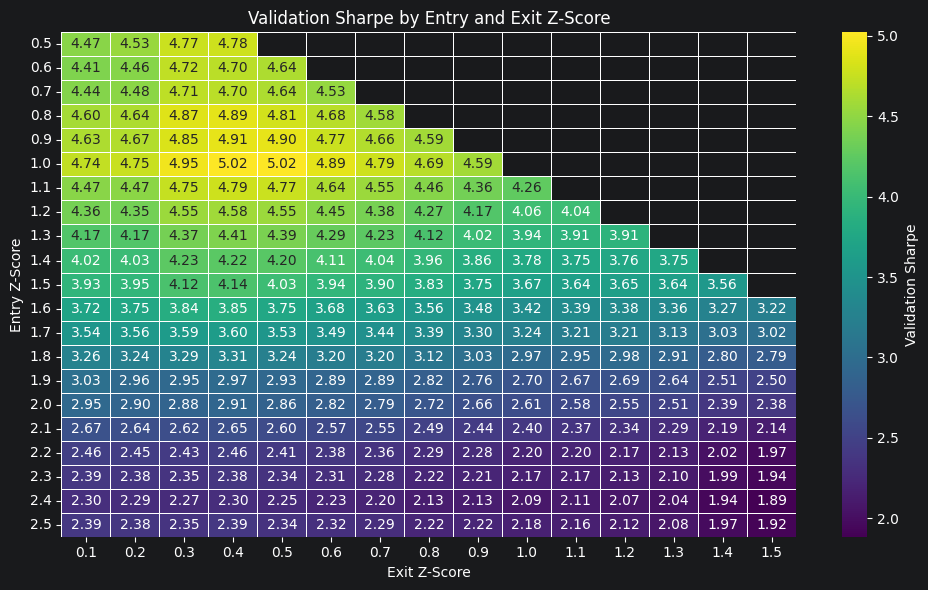

In [64]:
# Tuning for entry and exit z-scores

tuning_result = []

for idx, entry_z in enumerate(ENTRY_ZS):
    for exit_z in EXIT_ZS:
        if exit_z >= entry_z:
            continue

        train_candidate = prepare_kalman_set(training_set, q_alpha, q_beta, r, Z_LOOKBACK)
        valid_candidate = prepare_kalman_set(validation_set, q_alpha, q_beta, r, Z_LOOKBACK)

        train_stats = run_spread_backtest(train_candidate, entry_z, exit_z)
        valid_stats = run_spread_backtest(valid_candidate, entry_z, exit_z)

        tuning_result.append({
            "entry_z": entry_z,
            "exit_z": exit_z,
            "train_sharpe": train_stats["sharpe"],
            "train_total_pnl": train_stats["total_pnl"],
            "train_max_drawdown": train_stats["max_drawdown"],
            "train_entries": train_stats["entries"],
            "valid_sharpe": valid_stats["sharpe"],
            "valid_total_pnl": valid_stats["total_pnl"],
            "valid_max_drawdown": valid_stats["max_drawdown"],
            "valid_entries": valid_stats["entries"],
        })

tuning_result = pd.DataFrame(tuning_result)
tuning_result["passes_train_filter"] = (
    (tuning_result["train_entries"] >= 20)
    & (tuning_result["train_sharpe"] > 0)
)

ranked_tuning_results = (
    tuning_result[tuning_result["passes_train_filter"]]
    .sort_values("valid_sharpe", ascending=False)
    .reset_index(drop=True)
)

# Create pivot table for validation Sharpe
valid_sharpe_map = tuning_result.pivot(
    index="entry_z",
    columns="exit_z",
    values="valid_sharpe"
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    valid_sharpe_map,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "Validation Sharpe"}
)

plt.title("Validation Sharpe by Entry and Exit Z-Score")
plt.xlabel("Exit Z-Score")
plt.ylabel("Entry Z-Score")
plt.tight_layout()
plt.show()

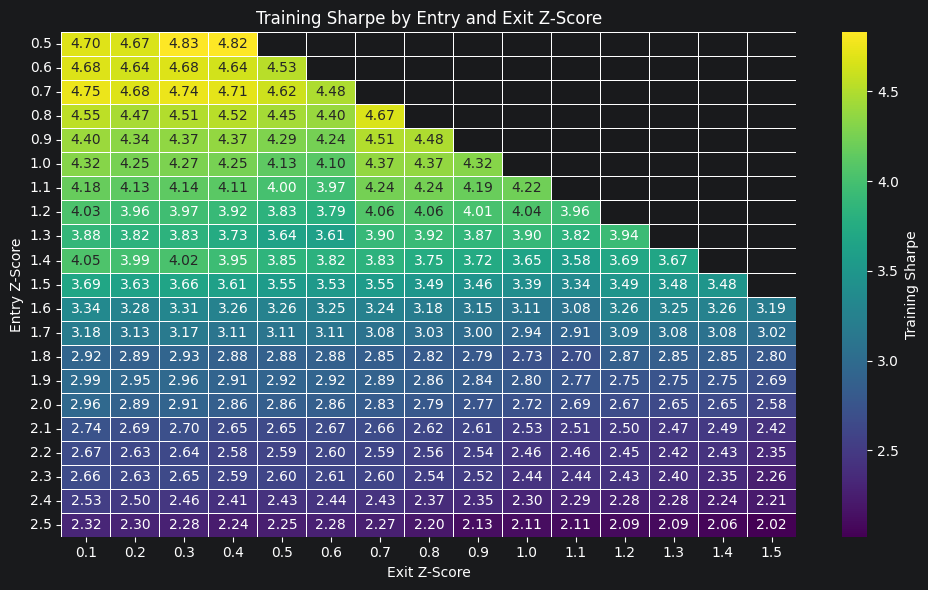

In [65]:
train_sharpe_map = tuning_result.pivot(
    index="entry_z",
    columns="exit_z",
    values="train_sharpe"
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    train_sharpe_map,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "Training Sharpe"}
)

plt.title("Training Sharpe by Entry and Exit Z-Score")
plt.xlabel("Exit Z-Score")
plt.ylabel("Entry Z-Score")
plt.tight_layout()
plt.show()

In [ ]:
# Set entry_z and exit_z through hyperparameter tuning.

ENTRY_Z = 1.0
EXIT_Z = 0.4

,sizing_method,max_position,z_cap,vol_lookback,train_sharpe,train_total_pnl,train_max_drawdown,train_entries,train_avg_abs_position,valid_sharpe,valid_total_pnl,valid_max_drawdown,valid_entries,valid_avg_abs_position,passes_train_filter
0,vol_scaled,1000,NaN,20.0,4.1594,151.5716,-1.3358,134,147.5494,4.0979,210.4073,-5.2422,145,159.9260,True
1,binary,1000,NaN,NaN,3.5458,211.0085,-5.2696,134,178.8079,4.0345,288.8142,-5.5668,145,191.9259,True
2,vol_scaled,1000,NaN,40.0,4.0308,158.2209,-1.6460,134,150.1687,4.0252,219.5731,-4.9927,145,159.7158,True
3,z_linear_vol_scaled,1000,2.0,20.0,4.2045,127.4610,-0.7704,134,109.2582,4.0121,166.1599,-3.7455,145,118.9404,True
4,vol_scaled,1000,NaN,60.0,3.9287,155.1151,-1.7684,134,148.8270,3.9577,222.3515,-5.5668,145,159.1749,True
5,z_linear_vol_scaled,1000,2.0,40.0,4.0609,132.4191,-0.9516,134,109.0147,3.9019,174.4772,-3.6092,145,117.8210,True
6,z_linear_vol_scaled,1000,2.5,20.0,4.0647,112.7926,-0.5778,134,94.8440,3.9000,145.0987,-3.5602,145,104.3712,True
7,z_linear_vol_scaled,1000,2.0,60.0,3.8854,127.9224,-1.0382,134,105.3617,3.8528,172.7763,-4.1256,145,116.2220,True
8,z_linear,1000,1.5,NaN,3.5526,195.1672,-3.2394,134,143.4827,3.8369,252.3906,-4.6170,145,153.5165,True
9,z_linear_vol_scaled,1000,3.0,20.0,3.9168,98.8784,-0.4622,134,81.0099,3.8201,126.0775,-2.8482,145,90.3350,True


Best position sizing selected from validation: {'sizing_method': 'vol_scaled', 'max_position': 1000, 'z_cap': nan, 'vol_lookback': 20.0}


,target_ann_vol_pct,vol_lookback,train_sharpe,train_total_pnl,train_realized_ann_vol,train_max_drawdown,train_entries,train_avg_gross_exposure,valid_sharpe,valid_total_pnl,valid_realized_ann_vol,valid_max_drawdown,valid_entries,valid_avg_gross_exposure,passes_train_filter
0,0.100,10,1.7074,6323.9721,618.1420,-750.6260,134,17880.7947,1.5424,6999.7925,756.8775,-1048.5327,145,19192.5877,True
1,0.150,10,1.7074,6323.9721,618.1420,-750.6260,134,17880.7947,1.5424,6999.7925,756.8775,-1048.5327,145,19192.5877,True
2,0.200,10,1.7074,6323.9721,618.1420,-750.6260,134,17880.7947,1.5424,6999.7925,756.8775,-1048.5327,145,19192.5877,True
3,0.075,10,1.7074,6323.9721,618.1420,-750.6260,134,17880.7947,1.5424,6999.7925,756.8775,-1048.5327,145,19192.5877,True
4,0.050,10,1.7074,6323.9721,618.1420,-750.6260,134,17880.7947,1.5382,6895.3677,747.6005,-1048.5327,145,19119.9134,True
5,0.200,20,1.7074,6323.9721,618.1420,-750.6260,134,17880.7947,1.4879,6534.0685,732.4024,-1048.5327,145,19060.2250,True
6,0.075,20,1.7074,6323.9721,618.1420,-750.6260,134,17880.7947,1.4879,6534.0685,732.4024,-1048.5327,145,19060.2250,True
7,0.150,20,1.7074,6323.9721,618.1420,-750.6260,134,17880.7947,1.4879,6534.0685,732.4024,-1048.5327,145,19060.2250,True
8,0.100,20,1.7074,6323.9721,618.1420,-750.6260,134,17880.7947,1.4879,6534.0685,732.4024,-1048.5327,145,19060.2250,True
9,0.050,20,1.7074,6323.9721,618.1420,-750.6260,134,17880.7947,1.4867,6523.8567,731.8237,-1048.5327,145,19037.1362,True


Best dollar vol-target sizing selected from validation: {'target_ann_vol_pct': 0.1, 'vol_lookback': 10}


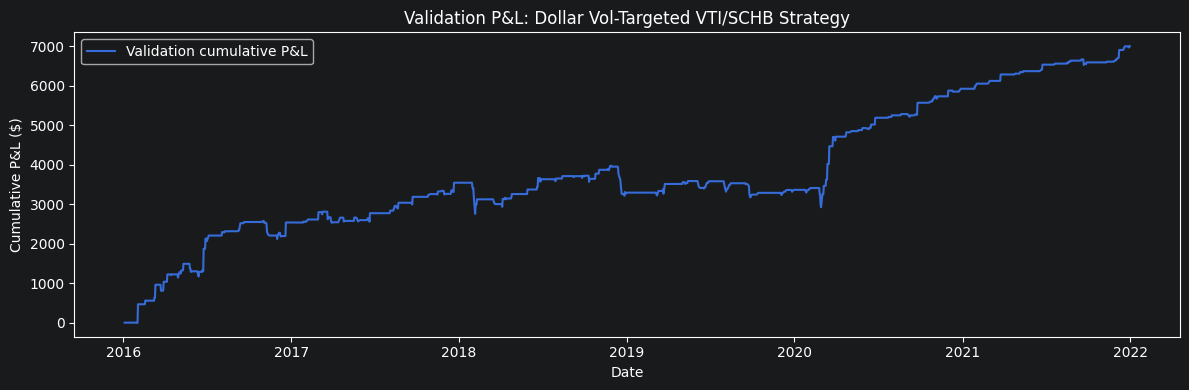

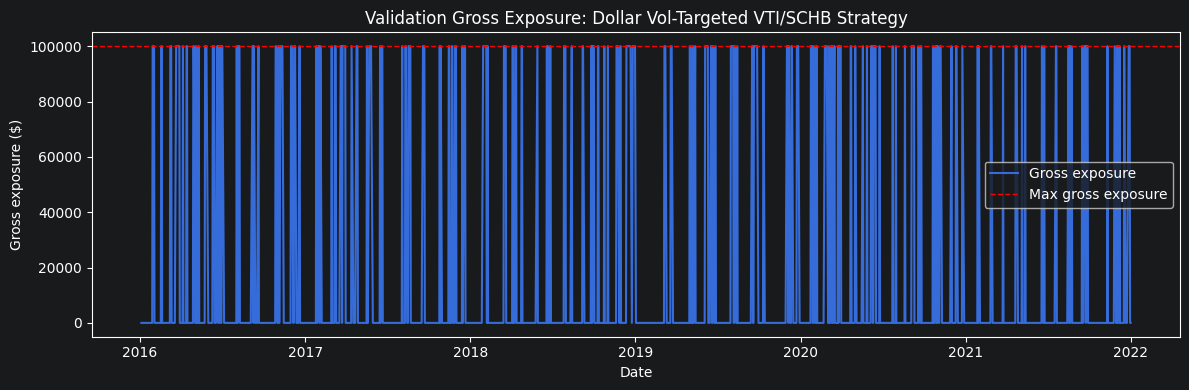

In [69]:
# Tune dollar-based volatility-targeted position sizing with max gross exposure of $100,000

MAX_GROSS_EXPOSURE = 100000

# Annualized dollar-volatility targets as a fraction of max gross exposure.
# Example: 0.10 targets about $10,000 annualized P&L volatility.
VOL_TARGET_GRID = [0.025, 0.05, 0.075, 0.10, 0.15, 0.20]
VOL_LOOKBACK_GRID = [10, 20, 40, 60]


def add_pair_returns(source_df):
    result = source_df.copy()
    result["VTI_ret"] = result["VTI"].pct_change()
    result["SCHB_ret"] = result["SCHB"].pct_change()
    return result


def generate_signal_direction(df, entry_z=ENTRY_Z, exit_z=EXIT_Z):
    directions = []
    current_direction = 0

    for z in df["z"]:
        if pd.isna(z):
            directions.append(current_direction)
            continue

        if current_direction == 0:
            if z > entry_z:
                current_direction = -1  # short spread: short VTI, long SCHB
            elif z < -entry_z:
                current_direction = 1  # long spread: long VTI, short SCHB
        elif current_direction > 0 and z >= -exit_z:
            current_direction = 0
        elif current_direction < 0 and z <= exit_z:
            current_direction = 0

        directions.append(current_direction)

    return pd.Series(directions, index=df.index)


def run_dollar_vol_target_backtest(
    kalman_df,
    max_gross_exposure=MAX_GROSS_EXPOSURE,
    target_ann_vol=0.10,
    vol_lookback=20,
    entry_z=ENTRY_Z,
    exit_z=EXIT_Z,
):
    result = add_pair_returns(kalman_df)
    result["direction"] = generate_signal_direction(result, entry_z=entry_z, exit_z=exit_z)

    beta = result["beta_kalman"].abs().replace(0, np.nan)
    result["vti_weight"] = 1 / (1 + beta)
    result["schb_weight"] = beta / (1 + beta)

    result["unit_spread_ret"] = (
        result["vti_weight"] * result["VTI_ret"]
        - result["schb_weight"] * result["SCHB_ret"]
    )
    result["unit_spread_vol"] = result["unit_spread_ret"].rolling(vol_lookback).std()

    target_daily_dollar_vol = max_gross_exposure * target_ann_vol / np.sqrt(252)
    result["target_gross_exposure"] = target_daily_dollar_vol / result["unit_spread_vol"]
    result["target_gross_exposure"] = result["target_gross_exposure"].clip(upper=max_gross_exposure)
    result["target_gross_exposure"] = result["target_gross_exposure"].replace([np.inf, -np.inf], np.nan).fillna(0)

    result["gross_exposure"] = np.where(
        result["direction"] == 0,
        0,
        result["target_gross_exposure"]
    )
    result["vti_dollars"] = result["direction"] * result["gross_exposure"] * result["vti_weight"]
    result["schb_dollars"] = -result["direction"] * result["gross_exposure"] * result["schb_weight"]

    result["pnl"] = (
        result["vti_dollars"].shift(1).fillna(0) * result["VTI_ret"]
        + result["schb_dollars"].shift(1).fillna(0) * result["SCHB_ret"]
    ).fillna(0)
    result["cum_pnl"] = result["pnl"].cumsum()
    result["drawdown"] = result["cum_pnl"] - result["cum_pnl"].cummax()

    daily_vol = result["pnl"].std()
    sharpe = np.nan if daily_vol == 0 or pd.isna(daily_vol) else np.sqrt(252) * result["pnl"].mean() / daily_vol
    entries = ((result["direction"] != 0) & (result["direction"].shift(1).fillna(0) == 0)).sum()

    return result, {
        "total_pnl": result["pnl"].sum(),
        "annual_pnl": result["pnl"].mean() * 252,
        "daily_vol": daily_vol,
        "realized_ann_vol": daily_vol * np.sqrt(252),
        "sharpe": sharpe,
        "max_drawdown": result["drawdown"].min(),
        "entries": int(entries),
        "exposure": result["gross_exposure"].gt(0).mean(),
        "avg_gross_exposure": result["gross_exposure"].mean(),
        "max_gross_exposure": result["gross_exposure"].max(),
    }


train_dollar_sizing_set = prepare_kalman_set(training_set, q_alpha, q_beta, r, Z_LOOKBACK)
valid_dollar_sizing_set = prepare_kalman_set(validation_set, q_alpha, q_beta, r, Z_LOOKBACK)

dollar_vol_sizing_results = []

for target_ann_vol in VOL_TARGET_GRID:
    for vol_lookback in VOL_LOOKBACK_GRID:
        _, train_stats = run_dollar_vol_target_backtest(
            train_dollar_sizing_set,
            max_gross_exposure=MAX_GROSS_EXPOSURE,
            target_ann_vol=target_ann_vol,
            vol_lookback=vol_lookback,
        )
        _, valid_stats = run_dollar_vol_target_backtest(
            valid_dollar_sizing_set,
            max_gross_exposure=MAX_GROSS_EXPOSURE,
            target_ann_vol=target_ann_vol,
            vol_lookback=vol_lookback,
        )

        dollar_vol_sizing_results.append({
            "target_ann_vol_pct": target_ann_vol,
            "vol_lookback": vol_lookback,
            "train_sharpe": train_stats["sharpe"],
            "train_total_pnl": train_stats["total_pnl"],
            "train_realized_ann_vol": train_stats["realized_ann_vol"],
            "train_max_drawdown": train_stats["max_drawdown"],
            "train_entries": train_stats["entries"],
            "train_avg_gross_exposure": train_stats["avg_gross_exposure"],
            "valid_sharpe": valid_stats["sharpe"],
            "valid_total_pnl": valid_stats["total_pnl"],
            "valid_realized_ann_vol": valid_stats["realized_ann_vol"],
            "valid_max_drawdown": valid_stats["max_drawdown"],
            "valid_entries": valid_stats["entries"],
            "valid_avg_gross_exposure": valid_stats["avg_gross_exposure"],
        })

dollar_vol_sizing_results = pd.DataFrame(dollar_vol_sizing_results)
dollar_vol_sizing_results["passes_train_filter"] = (
    (dollar_vol_sizing_results["train_entries"] >= 20)
    & (dollar_vol_sizing_results["train_sharpe"] > 0)
)

ranked_dollar_vol_sizing_results = (
    dollar_vol_sizing_results[dollar_vol_sizing_results["passes_train_filter"]]
    .sort_values("valid_sharpe", ascending=False)
    .reset_index(drop=True)
)

display(ranked_dollar_vol_sizing_results.round(4))

best_dollar_vol_sizing = ranked_dollar_vol_sizing_results.iloc[0][
    ["target_ann_vol_pct", "vol_lookback"]
].to_dict()
print("Best dollar vol-target sizing selected from validation:", best_dollar_vol_sizing)

best_valid_dollar_backtest, best_valid_dollar_stats = run_dollar_vol_target_backtest(
    valid_dollar_sizing_set,
    max_gross_exposure=MAX_GROSS_EXPOSURE,
    target_ann_vol=best_dollar_vol_sizing["target_ann_vol_pct"],
    vol_lookback=int(best_dollar_vol_sizing["vol_lookback"]),
)

plt.figure(figsize=(12, 4))
plt.plot(best_valid_dollar_backtest["Date"], best_valid_dollar_backtest["cum_pnl"], label="Validation cumulative P&L")
plt.title("Validation P&L: Dollar Vol-Targeted VTI/SCHB Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative P&L ($)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(best_valid_dollar_backtest["Date"], best_valid_dollar_backtest["gross_exposure"], label="Gross exposure")
plt.axhline(MAX_GROSS_EXPOSURE, color="red", linestyle="--", linewidth=1, label="Max gross exposure")
plt.title("Validation Gross Exposure: Dollar Vol-Targeted VTI/SCHB Strategy")
plt.xlabel("Date")
plt.ylabel("Gross exposure ($)")
plt.legend()
plt.tight_layout()
plt.show()
